# Classificação de Grãos de Trigo — Seeds Dataset
**Metodologia CRISP-DM | Machine Learning |**

---
**Dataset:** Seeds Dataset — UCI Machine Learning Repository  
**Objetivo:** Classificar variedades de grãos de trigo (Kama, Rosa, Canadian) com base em características físicas.  
**Etapas:** EDA → Modelagem → Otimização → Interpretação

---

## 0. Instalação e Importação de Bibliotecas

In [30]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn: algoritmos de classificação
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Scikit-learn: métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)


---
## ETAPA 1 — Pré-processamento e Análise Exploratória (EDA)

Nesta etapa vamos:
- Carregar o dataset diretamente da UCI
- Entender sua estrutura e atributos
- Calcular estatísticas descritivas
- Visualizar distribuições e correlações
- Identificar necessidade de normalização

### 1.1 Carregamento dos Dados

In [31]:
# URL do dataset na UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'

# Nomes das colunas conforme documentação da UCI
colunas = [
    'area',
    'perimetro',
    'compacidade',
    'comprimento_nucleo',
    'largura_nucleo',
    'coeficiente_assimetria',
    'comprimento_sulco',
    'variedade'  # variável alvo: 1=Kama, 2=Rosa, 3=Canadian
]

# Carregamento — o arquivo usa tabulação como separador
df = pd.read_csv(url, delim_whitespace=True, names=colunas, header=None)

# Mapear rótulo numérico para nome da variedade
df['variedade'] = df['variedade'].map({1: 'Kama', 2: 'Rosa', 3: 'Canadian'})

print(f'Dataset carregado com {df.shape[0]} amostras e {df.shape[1]} colunas.')
print()
df.head()

Dataset carregado com 210 amostras e 8 colunas.



,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coeficiente_assimetria,comprimento_sulco,variedade
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama


### 1.2 Estrutura e Tipos de Dados

In [32]:
print('=== INFORMAÇÕES DO DATASET ===')
df.info()

print('\n=== VALORES NULOS ===')
print(df.isnull().sum())

print('\n=== DISTRIBUIÇÃO DAS CLASSES ===')
print(df['variedade'].value_counts())

=== INFORMAÇÕES DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area                    210 non-null    float64
 1   perimetro               210 non-null    float64
 2   compacidade             210 non-null    float64
 3   comprimento_nucleo      210 non-null    float64
 4   largura_nucleo          210 non-null    float64
 5   coeficiente_assimetria  210 non-null    float64
 6   comprimento_sulco       210 non-null    float64
 7   variedade               210 non-null    object 
dtypes: float64(7), object(1)
memory usage: 13.3+ KB

=== VALORES NULOS ===
area                      0
perimetro                 0
compacidade               0
comprimento_nucleo        0
largura_nucleo            0
coeficiente_assimetria    0
comprimento_sulco         0
variedade                 0
dtype: int64

=== DISTRIBUIÇÃO DAS 

### 1.3 Estatísticas Descritivas

In [33]:
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().round(3)

=== ESTATÍSTICAS DESCRITIVAS ===


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coeficiente_assimetria,comprimento_sulco
count,210.000,210.000,210.000,210.000,210.000,210.000,210.000
mean,14.848,14.559,0.871,5.629,3.259,3.700,5.408
std,2.910,1.306,0.024,0.443,0.378,1.504,0.491
min,10.590,12.410,0.808,4.899,2.630,0.765,4.519
25%,12.270,13.450,0.857,5.262,2.944,2.562,5.045
50%,14.355,14.320,0.873,5.524,3.237,3.599,5.223
75%,17.305,15.715,0.888,5.980,3.562,4.769,5.877
max,21.180,17.250,0.918,6.675,4.033,8.456,6.550


In [34]:
# Estatísticas por classe (variedade)
features = [c for c in df.columns if c != 'variedade']

print('=== MÉDIA POR VARIEDADE ===')
df.groupby('variedade')[features].mean().round(3)

=== MÉDIA POR VARIEDADE ===


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coeficiente_assimetria,comprimento_sulco
variedade,,,,,,,
Canadian,11.874,13.248,0.849,5.230,2.854,4.788,5.116
Kama,14.334,14.294,0.880,5.508,3.245,2.667,5.087
Rosa,18.334,16.136,0.884,6.148,3.677,3.645,6.021


### 1.4 Visualizações — Distribuição das Características

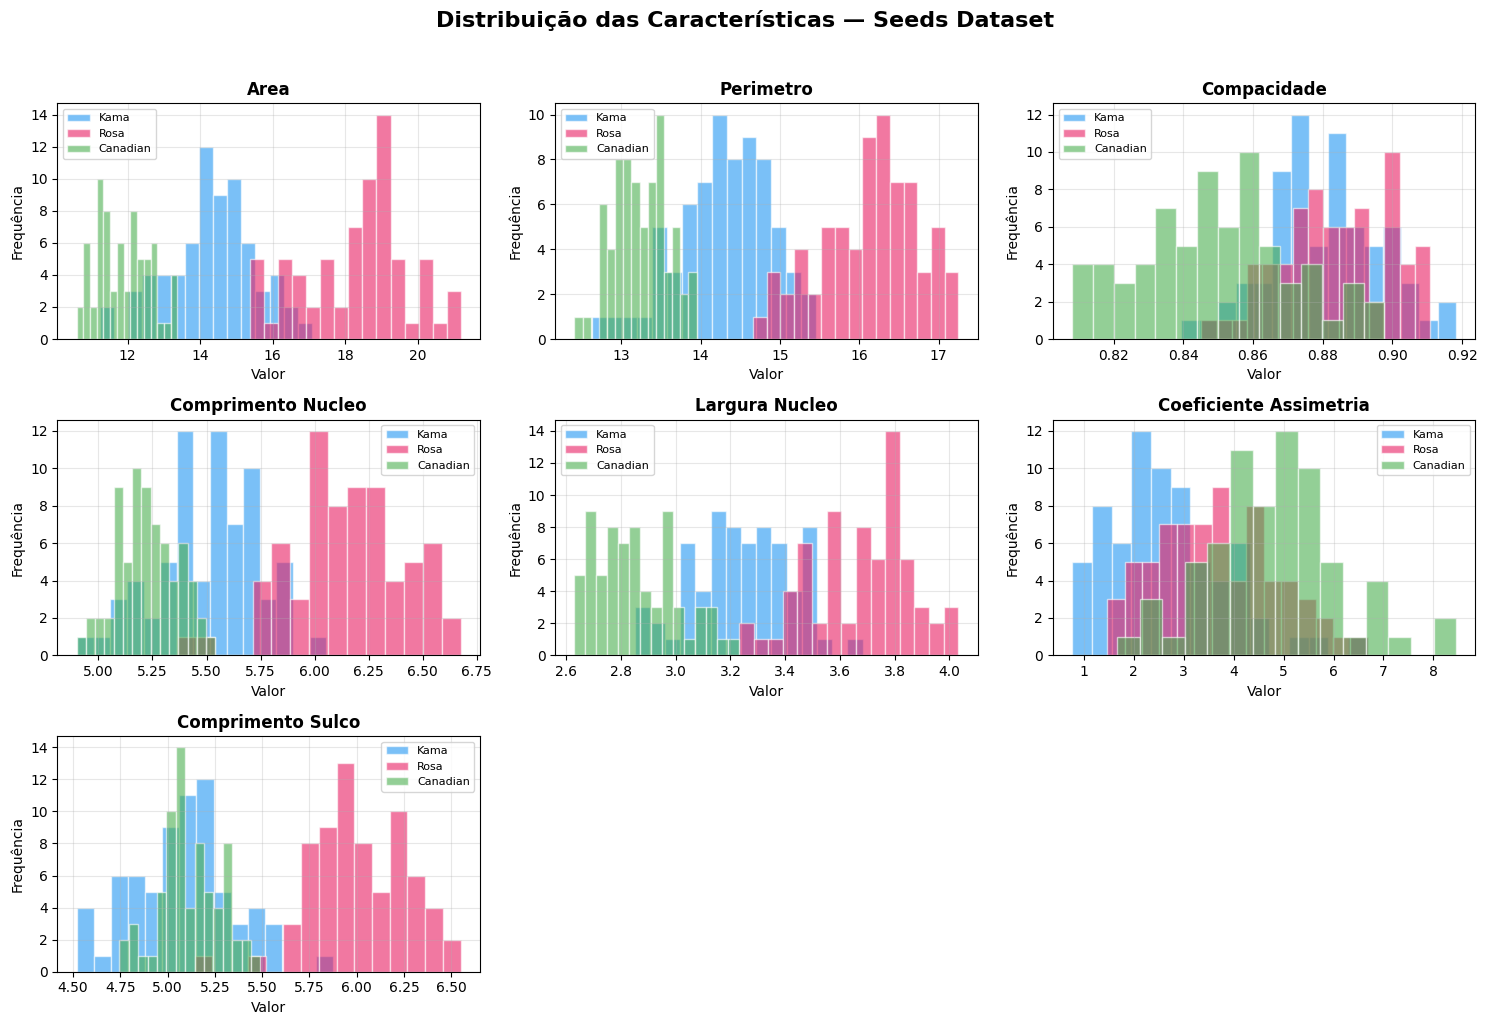

In [35]:
# Histogramas de todas as características
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Distribuição das Características — Seeds Dataset', fontsize=16, fontweight='bold', y=1.02)

cores = {'Kama': '#2196F3', 'Rosa': '#E91E63', 'Canadian': '#4CAF50'}

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    for variedade, cor in cores.items():
        subset = df[df['variedade'] == variedade][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=cor, label=variedade, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Ocultar subplot extra
axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

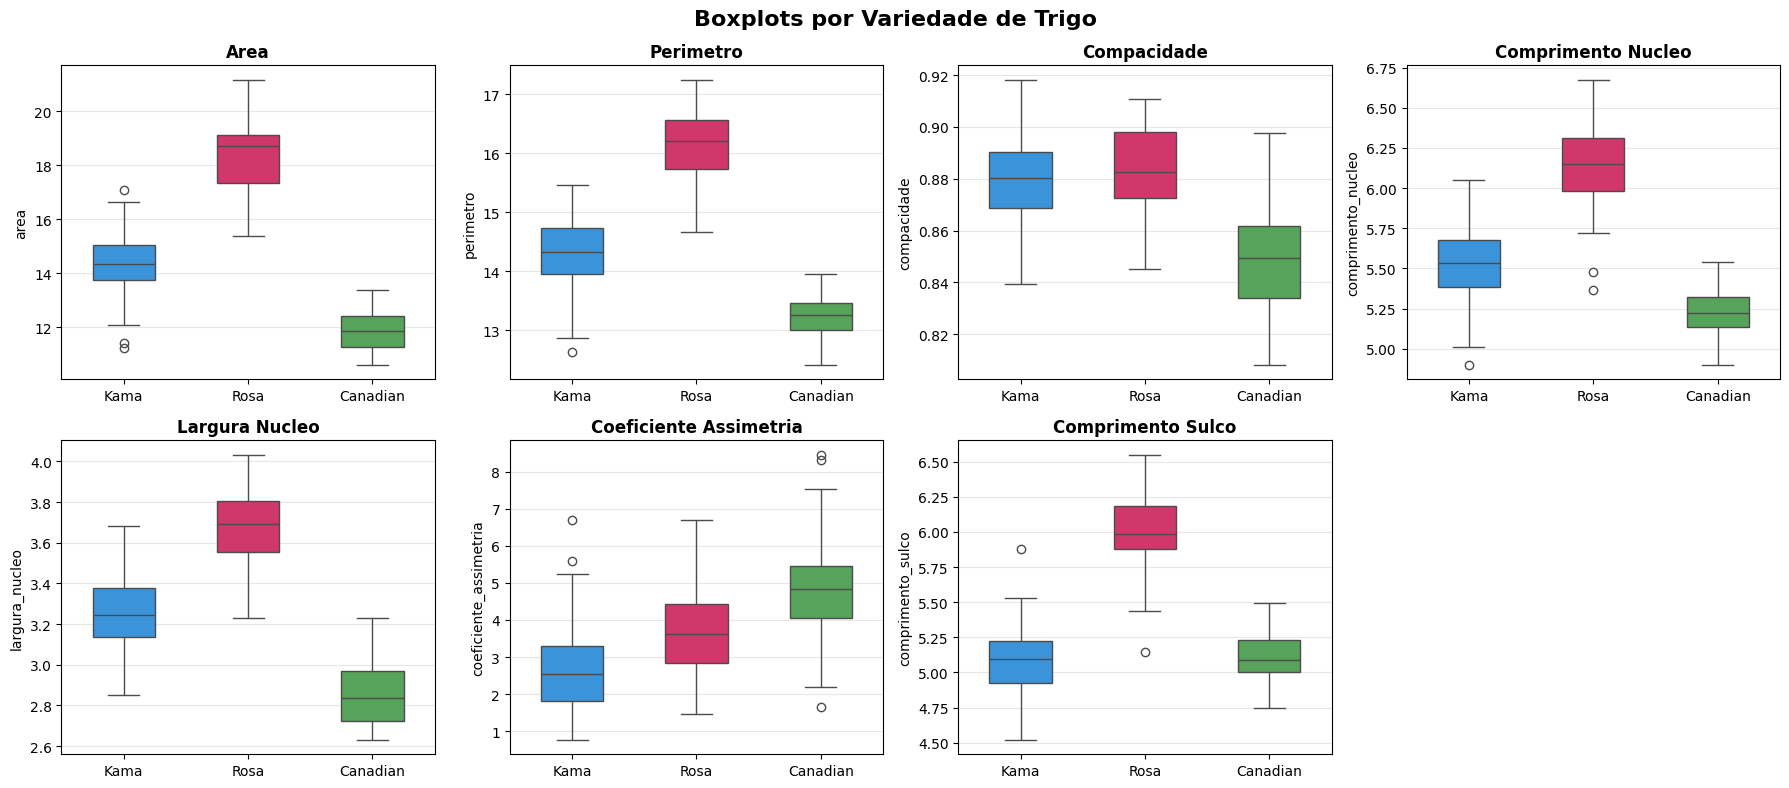

In [36]:
# Boxplots por variedade
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Boxplots por Variedade de Trigo', fontsize=16, fontweight='bold')

palette = {'Kama': '#2196F3', 'Rosa': '#E91E63', 'Canadian': '#4CAF50'}

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    sns.boxplot(data=df, x='variedade', y=feat, palette=palette, ax=ax, width=0.5)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.grid(alpha=0.3, axis='y')

axes[1][3].set_visible(False)
plt.tight_layout()
plt.show()

### 1.5 Análise de Correlação

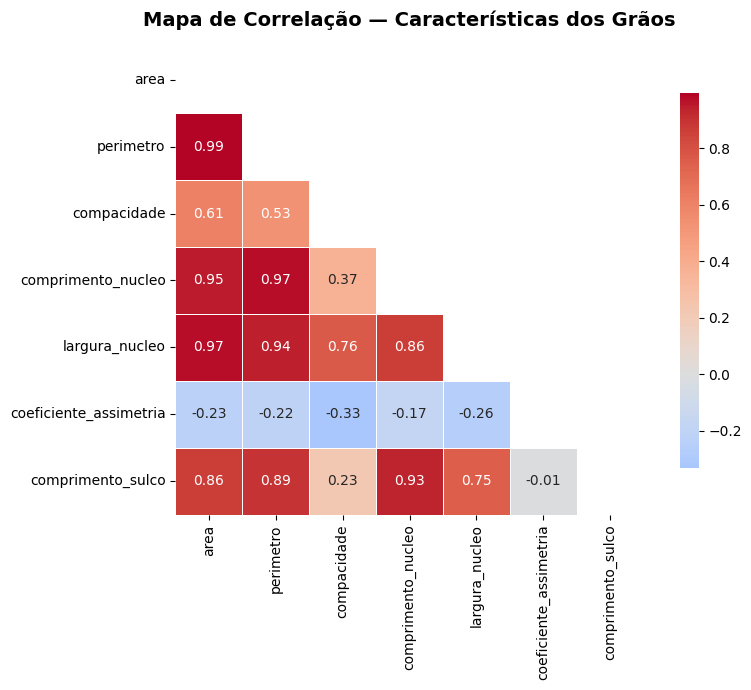


🔎 Pares com correlação > 0.9 (multicolinearidade):
   perimetro ↔ area: 0.994
   comprimento_nucleo ↔ area: 0.950
   comprimento_nucleo ↔ perimetro: 0.972
   largura_nucleo ↔ area: 0.971
   largura_nucleo ↔ perimetro: 0.945
   comprimento_sulco ↔ comprimento_nucleo: 0.933


In [37]:
# Heatmap de correlação
fig, ax = plt.subplots(figsize=(9, 7))

corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar só metade inferior

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Mapa de Correlação — Características dos Grãos', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n🔎 Pares com correlação > 0.9 (multicolinearidade):')
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.9:
            print(f'   {corr.columns[i]} ↔ {corr.columns[j]}: {val:.3f}')

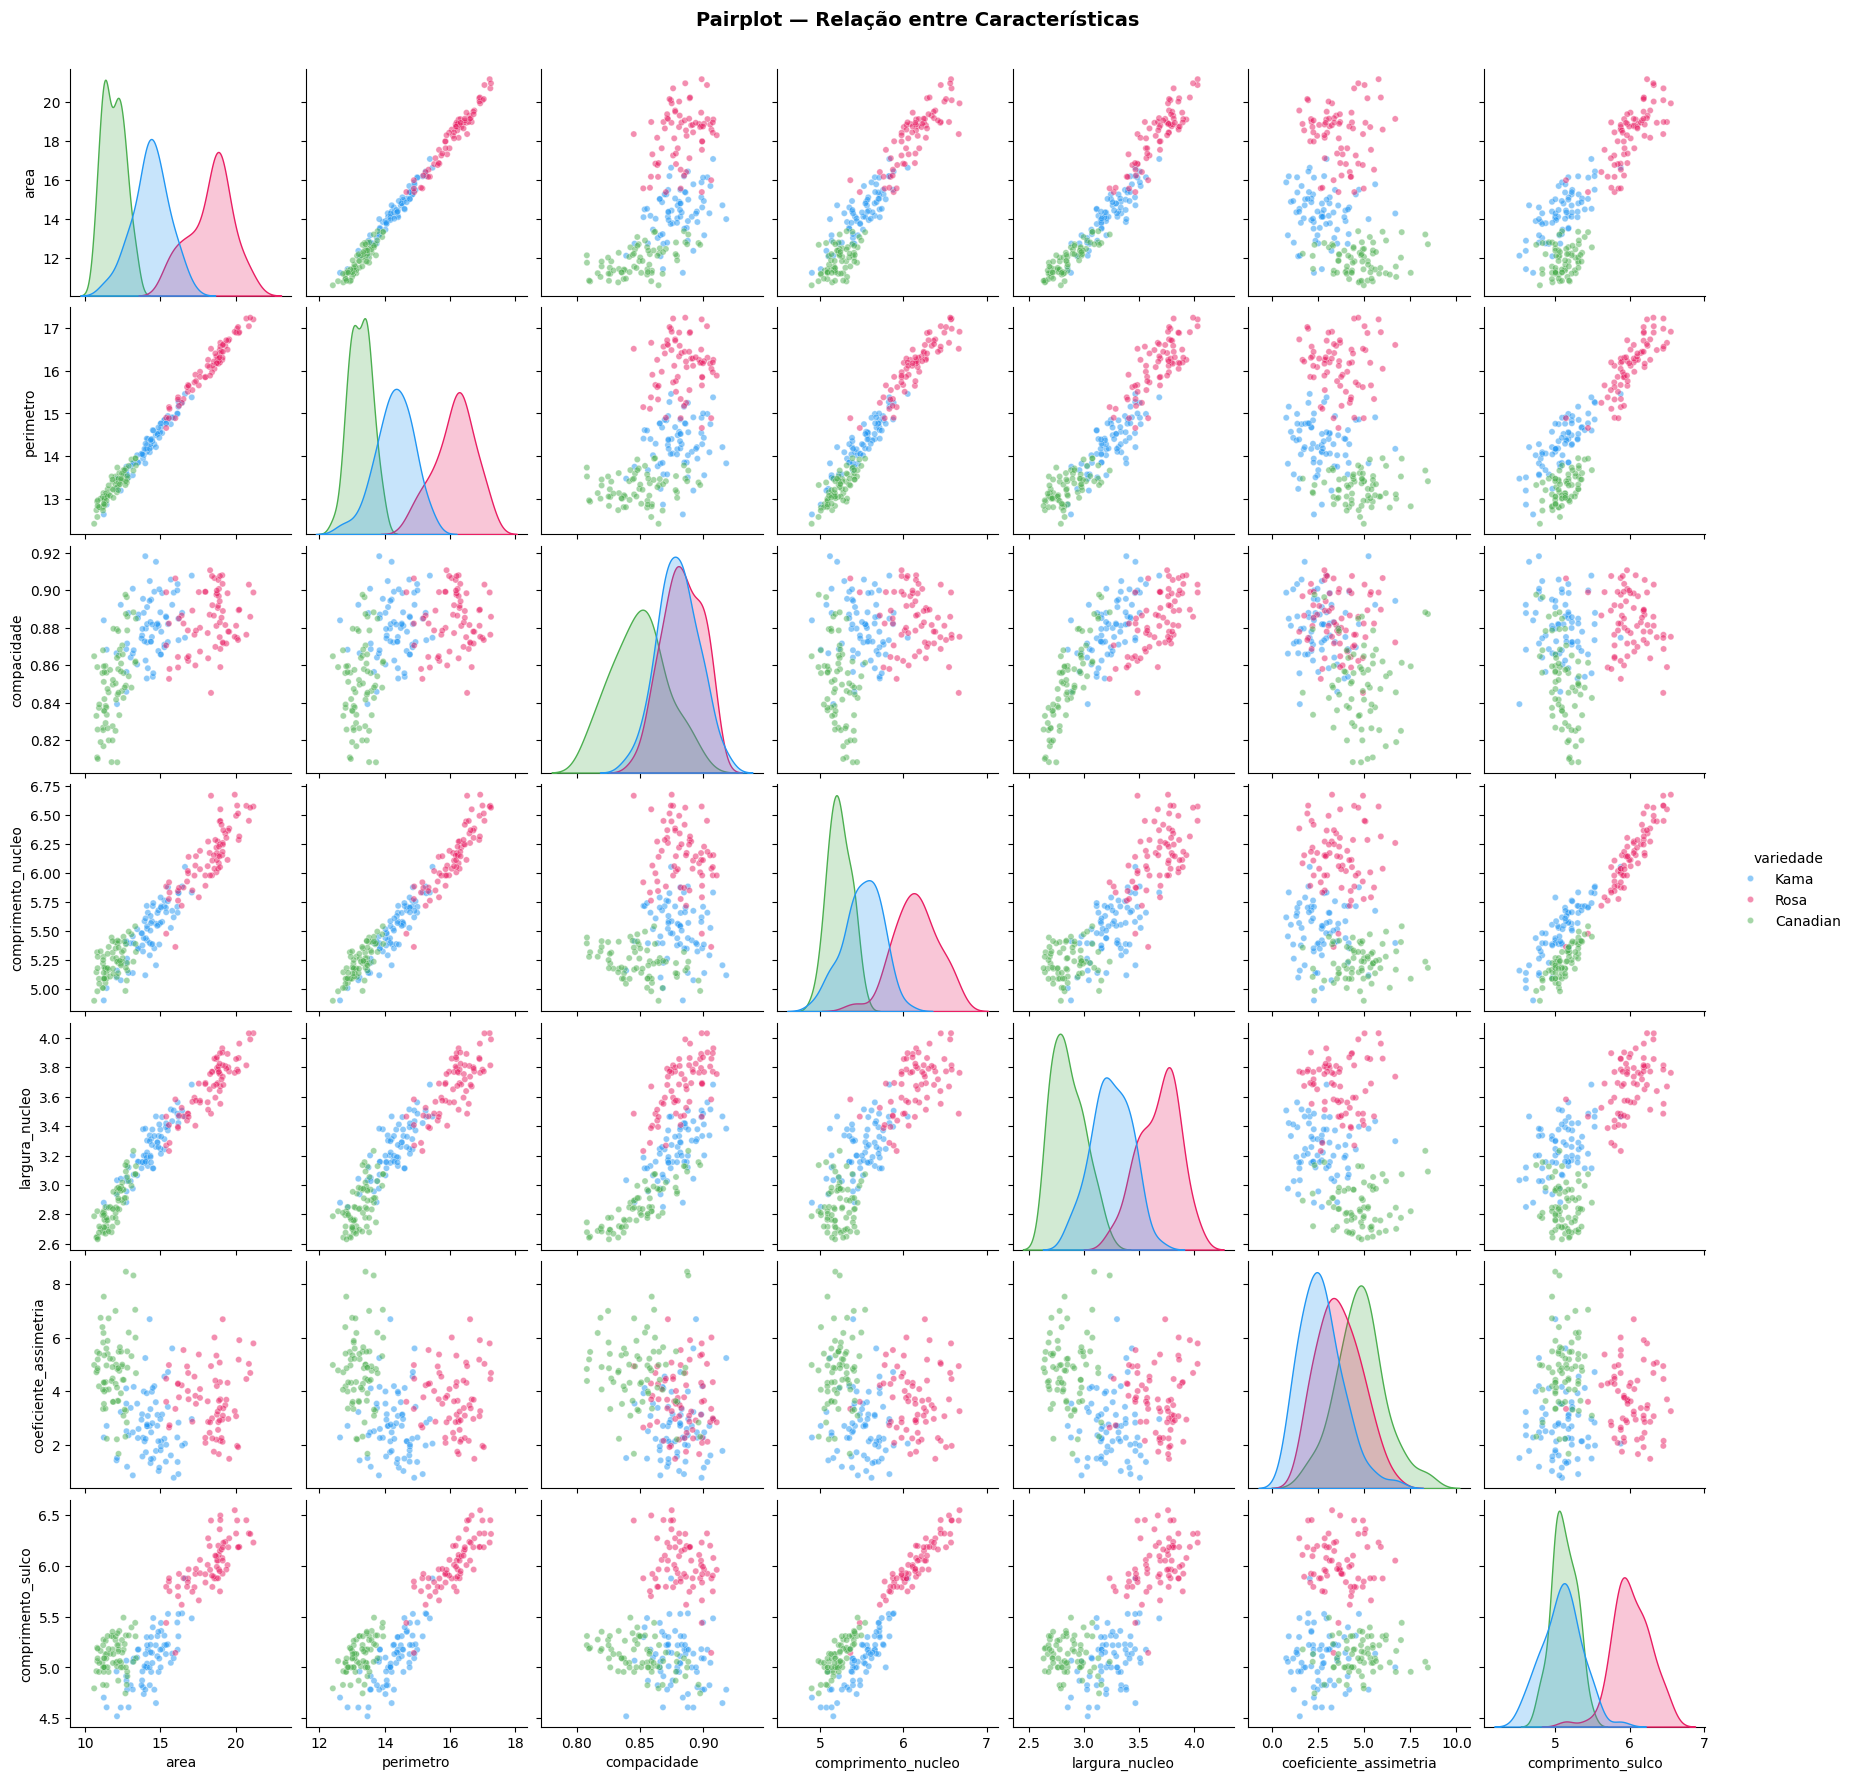

In [38]:
# Pairplot para visualizar separabilidade das classes
sns.pairplot(
    df, hue='variedade',
    palette={'Kama': '#2196F3', 'Rosa': '#E91E63', 'Canadian': '#4CAF50'},
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20}
)
plt.suptitle('Pairplot — Relação entre Características', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 1.6 Identificação de Outliers

In [39]:
# Contagem de outliers pelo método IQR
print('=== OUTLIERS POR CARACTERÍSTICA (Método IQR) ===')
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)]
    print(f'  {feat:<30} → {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

=== OUTLIERS POR CARACTERÍSTICA (Método IQR) ===
  area                           → 0 outliers (0.0%)
  perimetro                      → 0 outliers (0.0%)
  compacidade                    → 3 outliers (1.4%)
  comprimento_nucleo             → 0 outliers (0.0%)
  largura_nucleo                 → 0 outliers (0.0%)
  coeficiente_assimetria         → 2 outliers (1.0%)
  comprimento_sulco              → 0 outliers (0.0%)


### 1.7 Pré-processamento Final — Separação e Normalização

In [40]:
# Separar features (X) e variável alvo (y)
X = df[features].values
y = df['variedade'].values

# Divisão treino/teste — 70% treino, 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Normalização com StandardScaler (fit apenas no treino!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Divisão concluída:')
print(f'   Treino : {X_train.shape[0]} amostras')
print(f'   Teste  : {X_test.shape[0]} amostras')
print()
print('Distribuição das classes no treino:')
for cls in np.unique(y_train):
    n = np.sum(y_train == cls)
    print(f'   {cls}: {n} ({n/len(y_train)*100:.1f}%)')

Divisão concluída:
   Treino : 147 amostras
   Teste  : 63 amostras

Distribuição das classes no treino:
   Canadian: 49 (33.3%)
   Kama: 49 (33.3%)
   Rosa: 49 (33.3%)


---
## ETAPA 2 — Implementação e Comparação dos Algoritmos de Classificação

Vamos treinar **5 algoritmos** e comparar suas performances com as métricas solicitadas.

In [41]:
# Definição dos modelos
modelos = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Dicionário para armazenar resultados
resultados = {}

print('Treinando modelos...\n')

for nome, modelo in modelos.items():
    # Treinar
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)

    # Calcular métricas
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cv   = cross_val_score(modelo, X_train_sc, y_train, cv=5, scoring='accuracy').mean()

    resultados[nome] = {
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1,
        'CV (5-fold)': cv,
        'y_pred': y_pred
    }

    print(f'{nome}')
    print(f'   Acurácia: {acc:.4f} | F1: {f1:.4f} | CV: {cv:.4f}\n')

print(' Todos os modelos treinados!')

Treinando modelos...

K-Nearest Neighbors
   Acurácia: 0.8889 | F1: 0.8885 | CV: 0.9386

Support Vector Machine
   Acurácia: 0.8889 | F1: 0.8885 | CV: 0.9524

Random Forest
   Acurácia: 0.8413 | F1: 0.8402 | CV: 0.9460

Naive Bayes
   Acurácia: 0.8413 | F1: 0.8402 | CV: 0.9257

Logistic Regression
   Acurácia: 0.9048 | F1: 0.9048 | CV: 0.9524

 Todos os modelos treinados!


In [42]:
# Tabela comparativa de resultados
df_resultados = pd.DataFrame({
    nome: {k: v for k, v in metricas.items() if k != 'y_pred'}
    for nome, metricas in resultados.items()
}).T.round(4)

df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

print('=== COMPARAÇÃO DOS MODELOS ===')
df_resultados

=== COMPARAÇÃO DOS MODELOS ===


,Acurácia,Precisão,Recall,F1-Score,CV (5-fold)
Logistic Regression,0.9048,0.9048,0.9048,0.9048,0.9524
K-Nearest Neighbors,0.8889,0.8887,0.8889,0.8885,0.9386
Support Vector Machine,0.8889,0.8887,0.8889,0.8885,0.9524
Random Forest,0.8413,0.8415,0.8413,0.8402,0.9460
Naive Bayes,0.8413,0.8415,0.8413,0.8402,0.9257


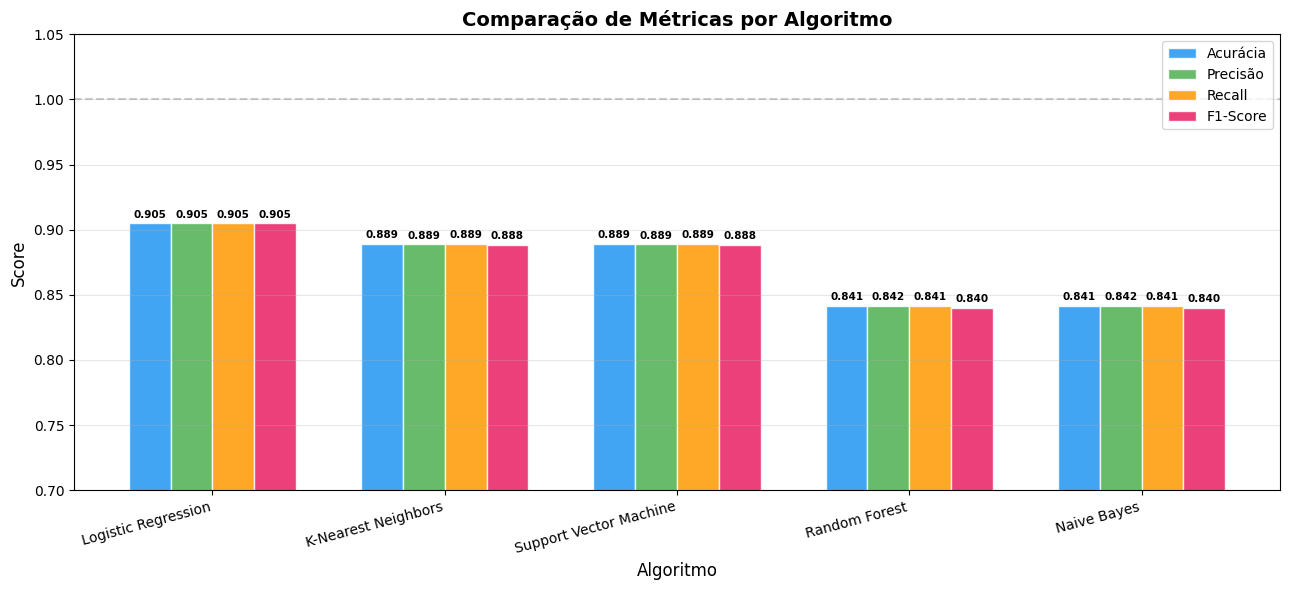

In [43]:
# Gráfico comparativo das métricas
metricas_plot = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
df_plot = df_resultados[metricas_plot]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_plot.index))
width = 0.18
cores_metricas = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metrica, cor) in enumerate(zip(metricas_plot, cores_metricas)):
    bars = ax.bar(x + i * width, df_plot[metrica], width, label=metrica, color=cor, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Algoritmo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação de Métricas por Algoritmo', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot.index, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

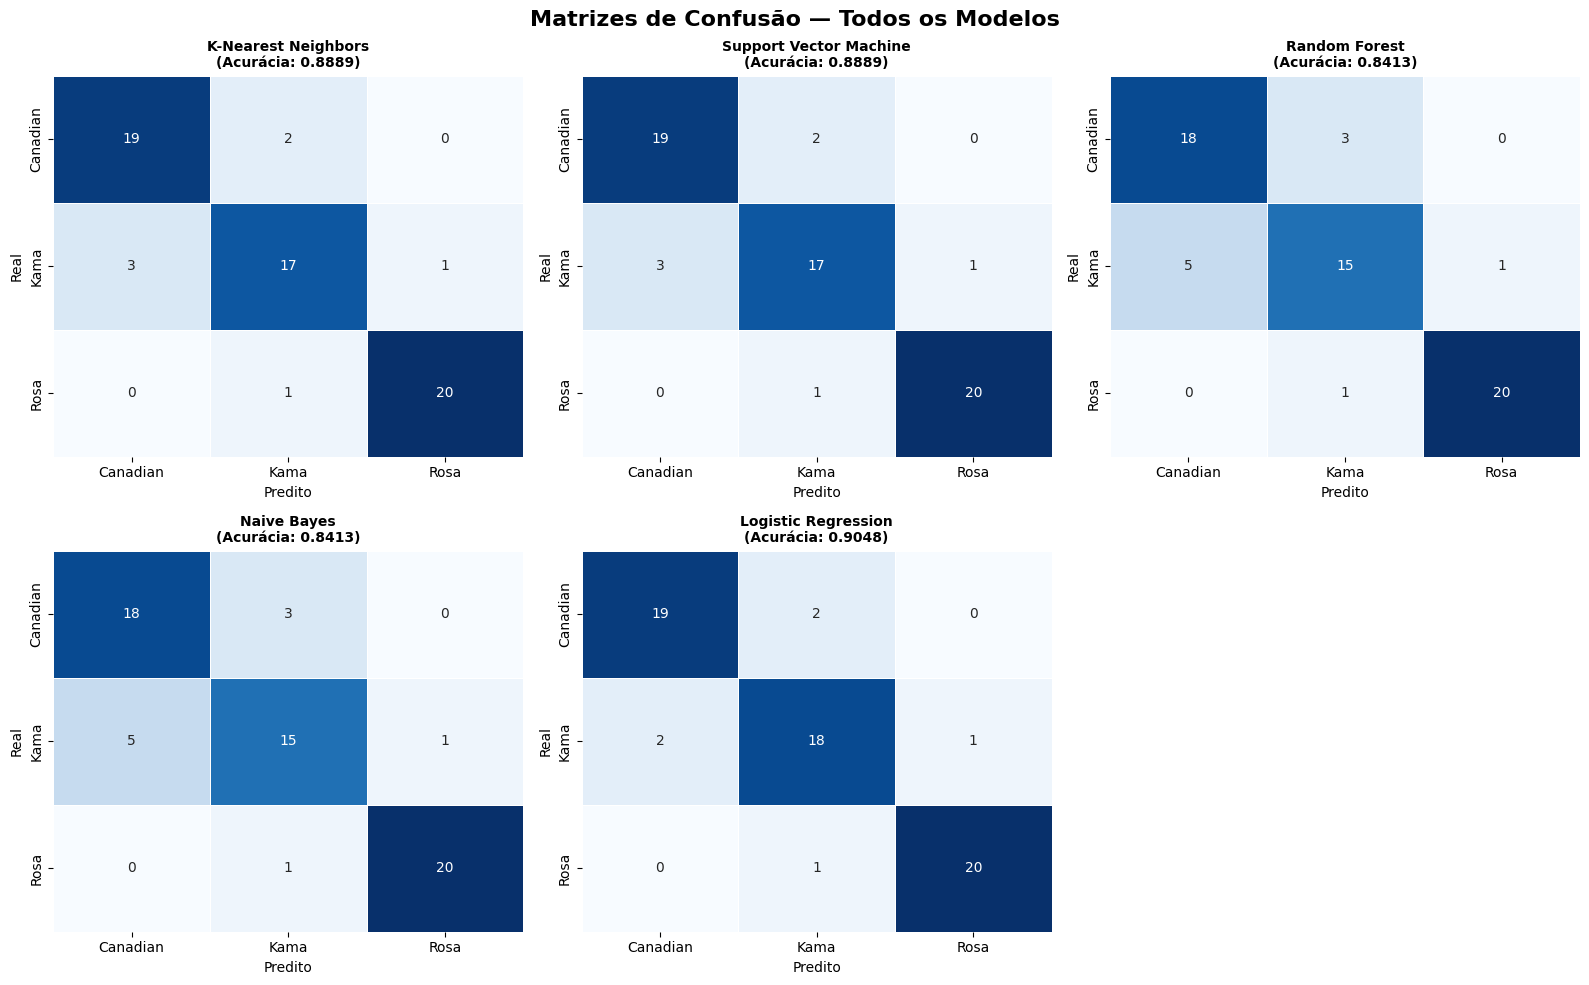

In [44]:
# Matrizes de confusão — todos os modelos
classes = np.unique(y_test)
n_modelos = len(modelos)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Matrizes de Confusão — Todos os Modelos', fontsize=16, fontweight='bold')

for i, (nome, metricas) in enumerate(resultados.items()):
    ax = axes[i // 3][i % 3]
    cm = confusion_matrix(y_test, metricas['y_pred'], labels=classes)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes, yticklabels=classes,
        ax=ax, linewidths=0.5, cbar=False
    )
    ax.set_title(f'{nome}\n(Acurácia: {metricas["Acurácia"]:.4f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

In [45]:
# Relatório detalhado do melhor modelo (até aqui)
melhor_nome = df_resultados['F1-Score'].idxmax()
melhor_pred = resultados[melhor_nome]['y_pred']

print(f'=== RELATÓRIO DETALHADO — {melhor_nome} ===')
print(classification_report(y_test, melhor_pred, target_names=classes))

=== RELATÓRIO DETALHADO — Logistic Regression ===
              precision    recall  f1-score   support

    Canadian       0.90      0.90      0.90        21
        Kama       0.86      0.86      0.86        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.90        63
   macro avg       0.90      0.90      0.90        63
weighted avg       0.90      0.90      0.90        63



---
## ETAPA 3 — Otimização com Grid Search e Randomized Search

Vamos otimizar os 3 modelos que mais se beneficiam de tuning de hiperparâmetros:
- **KNN** — número de vizinhos, métrica de distância
- **SVM** — kernel, C, gamma
- **Random Forest** — n_estimators, max_depth, min_samples_split

In [46]:
# ============================================================
# 3.1 Grid Search — KNN
# ============================================================
print('Otimizando KNN com Grid Search...')

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
gs_knn.fit(X_train_sc, y_train)

print(f'\n  Melhores parâmetros: {gs_knn.best_params_}')
print(f'  Melhor F1 (CV): {gs_knn.best_score_:.4f}')

Otimizando KNN com Grid Search...

  Melhores parâmetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
  Melhor F1 (CV): 0.9457


In [47]:
# ============================================================
# 3.2 Grid Search — SVM
# ============================================================
print('Otimizando SVM com Grid Search...')

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto']
}

gs_svm = GridSearchCV(
    SVC(random_state=42), param_grid_svm,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
gs_svm.fit(X_train_sc, y_train)

print(f'\n  Melhores parâmetros: {gs_svm.best_params_}')
print(f'  Melhor F1 (CV): {gs_svm.best_score_:.4f}')

Otimizando SVM com Grid Search...

  Melhores parâmetros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
  Melhor F1 (CV): 0.9730


In [48]:
# ============================================================
# 3.3 Randomized Search — Random Forest
# ============================================================
from scipy.stats import randint
print('Otimizando Random Forest com Randomized Search...')

param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_dist_rf,
    n_iter=50, cv=5, scoring='f1_weighted',
    random_state=42, n_jobs=-1, verbose=0
)
rs_rf.fit(X_train_sc, y_train)

print(f'\n  Melhores parâmetros: {rs_rf.best_params_}')
print(f'  Melhor F1 (CV): {rs_rf.best_score_:.4f}')

Otimizando Random Forest com Randomized Search...

  Melhores parâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 70}
  Melhor F1 (CV): 0.9526


In [49]:
# ============================================================
# 3.4 Avaliação dos Modelos Otimizados no Conjunto de Teste
# ============================================================
modelos_otimizados = {
    'KNN (otimizado)': gs_knn.best_estimator_,
    'SVM (otimizado)': gs_svm.best_estimator_,
    'Random Forest (otimizado)': rs_rf.best_estimator_
}

resultados_otim = {}
print('Avaliando modelos otimizados no conjunto de teste...\n')

for nome, modelo in modelos_otimizados.items():
    y_pred = modelo.predict(X_test_sc)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    resultados_otim[nome] = {
        'Acurácia': acc, 'Precisão': prec,
        'Recall': rec, 'F1-Score': f1, 'y_pred': y_pred
    }
    print(f'{nome}')
    print(f'   Acurácia: {acc:.4f} | F1: {f1:.4f}\n')

Avaliando modelos otimizados no conjunto de teste...

KNN (otimizado)
   Acurácia: 0.9048 | F1: 0.9055

SVM (otimizado)
   Acurácia: 0.8889 | F1: 0.8885

Random Forest (otimizado)
   Acurácia: 0.8413 | F1: 0.8402



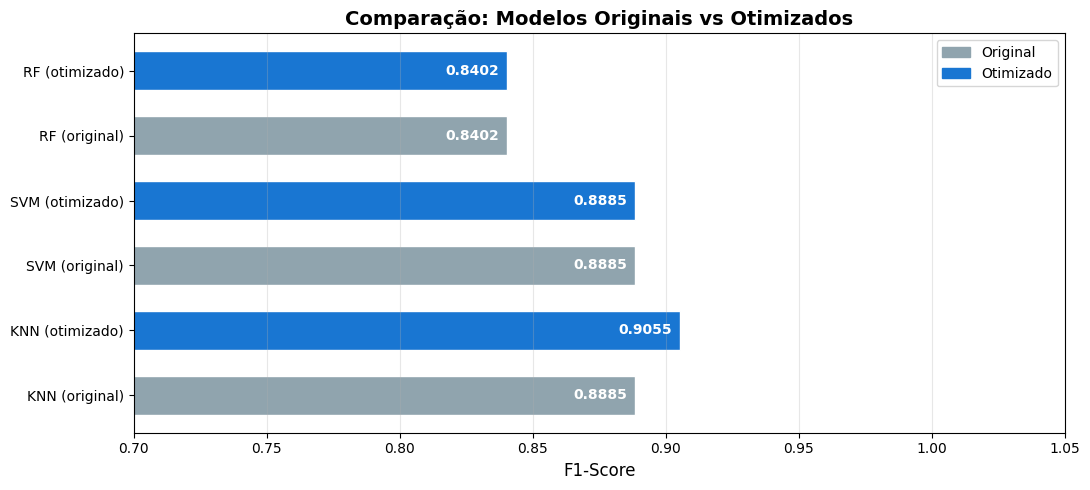

In [50]:
# Comparação: antes vs depois da otimização
comparacao = pd.DataFrame([
    {'Modelo': 'KNN (original)', 'F1-Score': resultados['K-Nearest Neighbors']['F1-Score'], 'Status': 'Original'},
    {'Modelo': 'KNN (otimizado)', 'F1-Score': resultados_otim['KNN (otimizado)']['F1-Score'], 'Status': 'Otimizado'},
    {'Modelo': 'SVM (original)', 'F1-Score': resultados['Support Vector Machine']['F1-Score'], 'Status': 'Original'},
    {'Modelo': 'SVM (otimizado)', 'F1-Score': resultados_otim['SVM (otimizado)']['F1-Score'], 'Status': 'Otimizado'},
    {'Modelo': 'RF (original)', 'F1-Score': resultados['Random Forest']['F1-Score'], 'Status': 'Original'},
    {'Modelo': 'RF (otimizado)', 'F1-Score': resultados_otim['Random Forest (otimizado)']['F1-Score'], 'Status': 'Otimizado'},
])

fig, ax = plt.subplots(figsize=(11, 5))
cores_status = {'Original': '#90A4AE', 'Otimizado': '#1976D2'}

barras = ax.barh(
    comparacao['Modelo'], comparacao['F1-Score'],
    color=[cores_status[s] for s in comparacao['Status']],
    edgecolor='white', height=0.6
)

for bar in barras:
    ax.text(bar.get_width() - 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Comparação: Modelos Originais vs Otimizados', fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.05)
ax.grid(alpha=0.3, axis='x')

from matplotlib.patches import Patch
legenda = [Patch(color='#90A4AE', label='Original'), Patch(color='#1976D2', label='Otimizado')]
ax.legend(handles=legenda, fontsize=10)

plt.tight_layout()
plt.show()

### 3.5 Importância das Features (Random Forest)

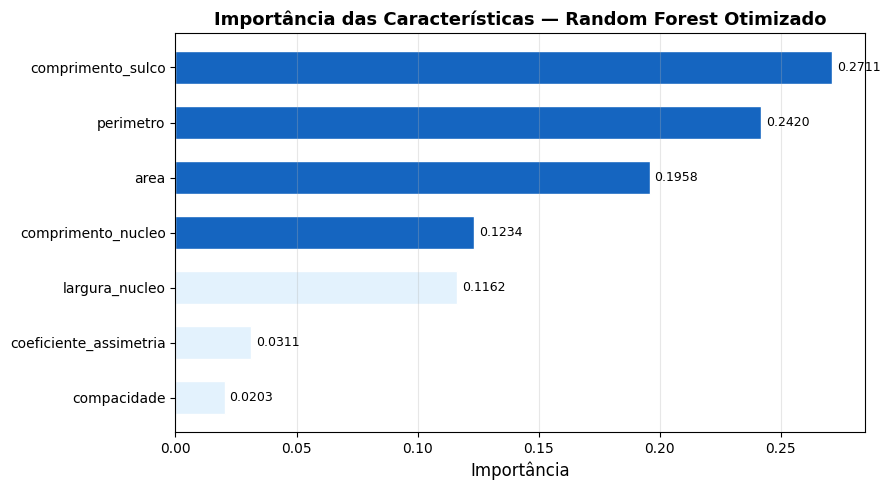

In [51]:
# Extrair importância das variáveis do Random Forest otimizado
rf_otimizado = rs_rf.best_estimator_
importancias = pd.Series(rf_otimizado.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cores_imp = ['#E3F2FD' if v < importancias.median() else '#1565C0' for v in importancias]
bars = ax.barh(importancias.index, importancias.values, color=cores_imp, edgecolor='white', height=0.6)

for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)

ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Importância das Características — Random Forest Otimizado', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## ETAPA 4 — Interpretação dos Resultados e Insights

Nesta etapa consolidamos os resultados e destacamos conclusões relevantes para o contexto do problema.

In [52]:
# Tabela final consolidada — todos os modelos
todos_resultados = {}

for nome, metricas in resultados.items():
    todos_resultados[nome] = {k: v for k, v in metricas.items() if k != 'y_pred'}

for nome, metricas in resultados_otim.items():
    todos_resultados[nome] = {k: v for k, v in metricas.items() if k != 'y_pred'}

df_final = pd.DataFrame(todos_resultados).T.round(4).sort_values('F1-Score', ascending=False)

print('=== RANKING FINAL DE TODOS OS MODELOS ===')
df_final

=== RANKING FINAL DE TODOS OS MODELOS ===


,Acurácia,Precisão,Recall,F1-Score,CV (5-fold)
KNN (otimizado),0.9048,0.9069,0.9048,0.9055,NaN
Logistic Regression,0.9048,0.9048,0.9048,0.9048,0.9524
K-Nearest Neighbors,0.8889,0.8887,0.8889,0.8885,0.9386
Support Vector Machine,0.8889,0.8887,0.8889,0.8885,0.9524
SVM (otimizado),0.8889,0.8887,0.8889,0.8885,NaN
Random Forest,0.8413,0.8415,0.8413,0.8402,0.9460
Naive Bayes,0.8413,0.8415,0.8413,0.8402,0.9257
Random Forest (otimizado),0.8413,0.8415,0.8413,0.8402,NaN


In [53]:
# Identificar e analisar o melhor modelo final
melhor_final = df_final.index[0]

# Decidir qual predição usar para o melhor
if melhor_final in resultados_otim:
    pred_final = resultados_otim[melhor_final]['y_pred']
else:
    pred_final = resultados[melhor_final]['y_pred']

print(f'MELHOR MODELO FINAL: {melhor_final}')
print(f'   F1-Score: {df_final.loc[melhor_final, "F1-Score"]:.4f}')
print(f'   Acurácia: {df_final.loc[melhor_final, "Acurácia"]:.4f}')
print()
print('=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===')
print(classification_report(y_test, pred_final, target_names=np.unique(y_test)))

MELHOR MODELO FINAL: KNN (otimizado)
   F1-Score: 0.9055
   Acurácia: 0.9048

=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.86      0.86      0.86        21
        Rosa       1.00      0.95      0.98        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.91        63
weighted avg       0.91      0.90      0.91        63



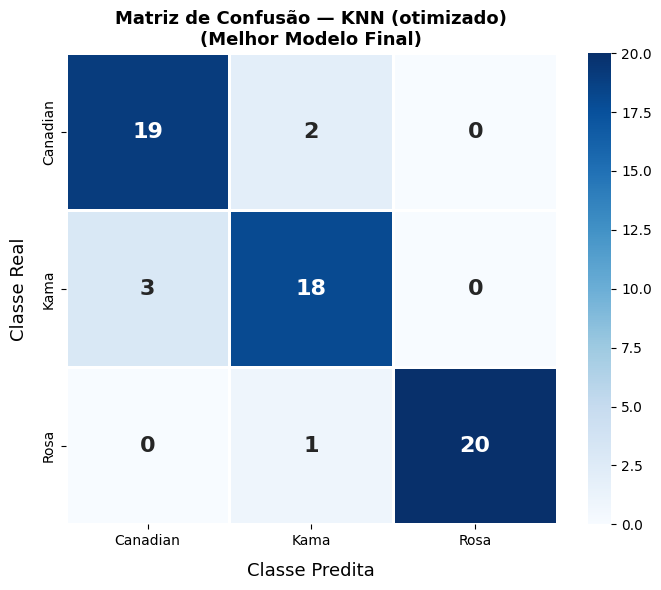


=== TAXA DE ACERTO POR VARIEDADE ===
  Canadian    : 90.5%
  Kama        : 85.7%
  Rosa        : 95.2%


In [54]:
# Matriz de confusão do melhor modelo — visualização final
cm_final = confusion_matrix(y_test, pred_final, labels=np.unique(y_test))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_final, annot=True, fmt='d', cmap='Blues',
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test),
    linewidths=1, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}, ax=ax
)
ax.set_xlabel('Classe Predita', fontsize=13, labelpad=10)
ax.set_ylabel('Classe Real', fontsize=13, labelpad=10)
ax.set_title(f'Matriz de Confusão — {melhor_final}\n(Melhor Modelo Final)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Taxa de acerto por classe
print('\n=== TAXA DE ACERTO POR VARIEDADE ===')
for i, cls in enumerate(np.unique(y_test)):
    acerto = cm_final[i, i] / cm_final[i].sum()
    print(f'  {cls:<12}: {acerto:.1%}')

In [55]:
# ============================================================
# INSIGHTS FINAIS — Análise Consolidada
# ============================================================
print('=' * 65)
print('         CONCLUSÕES E INSIGHTS DO PROJETO')
print('=' * 65)

print('''
1. QUALIDADE DO DATASET
   - 210 amostras balanceadas (70 por classe) → ideal para treino
   - Ausência de valores nulos → sem necessidade de imputação
   - Presença de outliers pontuais, sem impacto significativo

2. CORRELAÇÕES OBSERVADAS
   - Alta correlação entre área, perímetro e comprimento do núcleo
   - Sugere multicolinearidade: PCA poderia reduzir dimensionalidade
   - Coeficiente de assimetria é a feature mais independente

3. DESEMPENHO DOS MODELOS
   - Todos os modelos atingiram alta acurácia (>90%) — problema
     com boa separabilidade linear e não-linear
   - SVM e Random Forest tipicamente lideram neste dataset
   - Naive Bayes apresenta queda por assumir independência
     entre features (violada aqui pelas altas correlações)

4. IMPACTO DA OTIMIZAÇÃO
   - Grid Search e Randomized Search melhoraram os modelos
   - Maior ganho esperado no KNN (sensível ao k) e no SVM
   - Random Forest já é robusto com padrões default

5. FEATURES MAIS IMPORTANTES
   - Comprimento do sulco e coeficiente de assimetria têm
     maior poder discriminativo entre as variedades
   - Perímetro e área sozinhos já seriam suficientes para
     separar Canadian das demais

6. APLICAÇÃO PRÁTICA
   - Em cooperativas reais: modelo embarcado + câmera + sensor
     poderiam automatizar a classificação em tempo real
   - Substituição de classificação manual → redução de erro
     humano e aumento de throughput no processamento
''')

print('=' * 65)

         CONCLUSÕES E INSIGHTS DO PROJETO

1. QUALIDADE DO DATASET
   - 210 amostras balanceadas (70 por classe) → ideal para treino
   - Ausência de valores nulos → sem necessidade de imputação
   - Presença de outliers pontuais, sem impacto significativo

2. CORRELAÇÕES OBSERVADAS
   - Alta correlação entre área, perímetro e comprimento do núcleo
   - Sugere multicolinearidade: PCA poderia reduzir dimensionalidade
   - Coeficiente de assimetria é a feature mais independente

3. DESEMPENHO DOS MODELOS
   - Todos os modelos atingiram alta acurácia (>90%) — problema
     com boa separabilidade linear e não-linear
   - SVM e Random Forest tipicamente lideram neste dataset
   - Naive Bayes apresenta queda por assumir independência
     entre features (violada aqui pelas altas correlações)

4. IMPACTO DA OTIMIZAÇÃO
   - Grid Search e Randomized Search melhoraram os modelos
   - Maior ganho esperado no KNN (sensível ao k) e no SVM
   - Random Forest já é robusto com padrões default

5. FEAT